In [4]:
from pyspark import SparkContext

#sc = SparkContext("local", "Narrow Transformations Example")

# Base RDD
rdd = sc.parallelize([1, 2, 3, 4, 5])

# Apply narrow transformations
mapped_rdd = rdd.map(lambda x: x * 2)
filtered_rdd = mapped_rdd.filter(lambda x: x > 5)
#print(filtered_rdd)
print(filtered_rdd.collect())
# Output: [6, 8, 10]


[6, 8, 10]


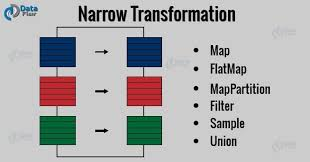

# flatMap() -- flatMap() is a narrow transformation in PySpark RDD that is similar to map(),

# but it allows each input element to be mapped to 0 or more output elements.

# It then flattens the results — meaning the output is a single list of elements (not nested lists).

In [ ]:
from pyspark import SparkContext

# sc = SparkContext("local", "flatMap Example")

# Create an RDD
rdd = sc.parallelize(["hello world", "how are you"])

# Using map()
map_rdd = rdd.map(lambda line: line.split(" "))
print("map():", map_rdd.collect())
# Output: [['hello', 'world'], ['how', 'are', 'you']]

# Using flatMap()
flat_rdd = rdd.flatMap(lambda line: line.split(" "))
print("flatMap():", flat_rdd.collect())
# Output: ['hello', 'world', 'how', 'are', 'you']


map(): [['hello', 'world'], ['how', 'are', 'you']]
flatMap(): ['hello', 'world', 'how', 'are', 'you']


#  mapPartitions()  is a narrow transformation that applies a given function once per partition (instead of once per element, like map()).

In [ ]:


from pyspark import SparkContext

#sc = SparkContext("local", "mapPartitions Example")

# Create an RDD with 8 elements and 4 partitions
rdd = sc.parallelize([1, 2, 3, 4,5,6,7,8], 4)

# Define a function that operates on each partition
def process_partition(iterator):
    for x in iterator:
        yield x * 2

# Apply mapPartitions
result = rdd.mapPartitions(process_partition)

print(result.collect())



[2, 4, 6, 8, 10, 12, 14, 16]


# mapValues() is a narrow transformation that is used only on Pair RDDs — i.e., RDDs containing key-value pairs of the form (K, V).

# It applies a function only to the values (V) of each key-value pair, while keeping the keys (K) unchanged.

In [6]:
from pyspark import SparkContext

#sc = SparkContext("local", "mapValues Example")

# Create a Pair RDD
rdd = sc.parallelize([("a", 1), ("b", 2), ("c", 3)])

# Apply mapValues
result = rdd.mapValues(lambda x: x - 10)

print(result.collect())



[('a', -9), ('b', -8), ('c', -7)]


In [ ]:
# Example 2: Using with Tuples

rdd = sc.parallelize([("x", (2, 3)), ("y", (4, 5))])

# Add up elements in each tuple
result = rdd.mapValues(lambda x: x[0] + x[1])

print(result.collect())
# Output: [('x', 5), ('y', 9)]


# union() is a narrow transformation in PySpark RDD that is used to combine two or more RDDs having the same data type into a single RDD.

# It’s similar to SQL’s UNION ALL —
# 👉 It does not remove duplicates (for that, you’d use .distinct() afterward).

# rdd3 = rdd1.union(rdd2)
# Both RDDs must have the same element type (e.g., both contain integers, or both contain tuples of the same schema).

# Returns a new RDD containing elements from both RDDs.

In [8]:
from pyspark import SparkContext

#sc = SparkContext("local", "union Example")

rdd1 = sc.parallelize([1, 2, 3])
rdd2 = sc.parallelize([3, 4, 5])

rdd3 = rdd1.union(rdd2)

print(rdd3.collect())
# Output: [1, 2, 3, 3, 4, 5]


[1, 2, 3, 3, 4, 5]


In [9]:
# Example 2: Remove Duplicates After Union

rdd1 = sc.parallelize(["apple", "banana"])
rdd2 = sc.parallelize(["banana", "cherry"])

rdd_union = rdd1.union(rdd2).distinct()

print(rdd_union.collect())
# Output: ['apple', 'banana', 'cherry']


['apple', 'banana', 'cherry']


# sample() is a narrow transformation in PySpark RDD that returns a random subset (sample) of the elements from the source RDD.

# It’s often used for: Testing or debugging (using small subsets of big data) > Exploratory data analysis >  Statistical sampling



In [18]:
from pyspark import SparkContext

#sc = SparkContext("local", "sample Example")

rdd = sc.parallelize(range(1, 11))

# Take 40% of elements without replacement
sample_rdd = rdd.sample(True, 0.4, 10)

print(sample_rdd.collect())
# Output: e.g. [2, 3, 6, 9]  (results vary)


[4, 4, 5, 8, 9]


# glom() is a narrow transformation that converts each partition of an RDD into a list (array) of all its elements.

# 👉 It groups all elements within a partition into a single list
 # 👉 So the output RDD has as many elements as there are partitions, and each element is a list of the partition’s data.

In [19]:
# No input parameters required

from pyspark import SparkContext
#sc = SparkContext("local", "glom Example")

rdd = sc.parallelize([1, 2, 3, 4, 5, 6,7,8], 4)

# Apply glom()
glommed = rdd.glom()

print(glommed.collect())

# output   [[1, 2], [3, 4], [5, 6]]

[[1, 2], [3, 4], [5, 6], [7, 8]]


In [20]:
# Find Maximum Element in Each Partition

rdd = sc.parallelize([10, 3, 5, 8, 2, 6], 4)

partition_max = rdd.glom().map(lambda x: max(x))

print(partition_max.collect())
# Output: [10, 8, 6]


[10, 5, 8, 6]
